# Análise de Negócio (Y.Afisha)
## Otimização de despesas com marketing

**Objetivo:** entender como os usuários usam o produto, quando começam a comprar, quanto valor trazem (LTV) e em quanto tempo os investimentos em marketing se pagam (CAC/ROI).

**Dados disponíveis:**
- `visits_log_us.csv` — logs de visitas (sessões, dispositivo, origem)
- `orders_log_us.csv` — pedidos e receita
- `costs_us.csv` — gastos diários por origem de anúncio

**Período:** Jan/2017 a Dez/2018


## Plano de trabalho

1. Carregar bibliotecas e dados  
2. Preparar os dados (tipos, duplicatas, colunas auxiliares)  
3. Métricas de produto (DAU/WAU/MAU, sessões/dia, duração, frequência)  
4. Métricas de vendas (conversão no tempo, pedidos por cliente, ticket médio, LTV)  
5. Marketing (custos por origem, CAC, ROI e payback)  
6. Conclusões e recomendações (onde investir e por quê)


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns




In [2]:
visits = pd.read_csv('/datasets/visits_log_us.csv')
orders = pd.read_csv('/datasets/orders_log_us.csv')
costs = pd.read_csv('/datasets/costs_us.csv')


<div class="alert alert-block alert-success">
<b> Comentário do revisor: </b> <a class="tocSkip"></a>
    
- O import das bibliotecas foi feito de forma correta e em uma célula separada
- Os dados foram carregados corretamente
</div>

In [3]:
visits.head()


,Device,End Ts,Source Id,Start Ts,Uid
0,touch,2017-12-20 17:38:00,4,2017-12-20 17:20:00,16879256277535980062
1,desktop,2018-02-19 17:21:00,2,2018-02-19 16:53:00,104060357244891740
2,touch,2017-07-01 01:54:00,5,2017-07-01 01:54:00,7459035603376831527
3,desktop,2018-05-20 11:23:00,9,2018-05-20 10:59:00,16174680259334210214
4,desktop,2017-12-27 14:06:00,3,2017-12-27 14:06:00,9969694820036681168


In [4]:
visits.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 359400 entries, 0 to 359399
Data columns (total 5 columns):
 #   Column     Non-Null Count   Dtype 
---  ------     --------------   ----- 
 0   Device     359400 non-null  object
 1   End Ts     359400 non-null  object
 2   Source Id  359400 non-null  int64 
 3   Start Ts   359400 non-null  object
 4   Uid        359400 non-null  uint64
dtypes: int64(1), object(3), uint64(1)
memory usage: 13.7+ MB


In [5]:
visits['Start Ts'] = pd.to_datetime(visits['Start Ts'])
visits['End Ts'] = pd.to_datetime(visits['End Ts'])


In [6]:
visits.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 359400 entries, 0 to 359399
Data columns (total 5 columns):
 #   Column     Non-Null Count   Dtype         
---  ------     --------------   -----         
 0   Device     359400 non-null  object        
 1   End Ts     359400 non-null  datetime64[ns]
 2   Source Id  359400 non-null  int64         
 3   Start Ts   359400 non-null  datetime64[ns]
 4   Uid        359400 non-null  uint64        
dtypes: datetime64[ns](2), int64(1), object(1), uint64(1)
memory usage: 13.7+ MB


In [7]:
# data da sessão (sem hora)
visits['session_date'] = visits['Start Ts'].dt.date

# duração da sessão em minutos
visits['session_duration'] = (
    visits['End Ts'] - visits['Start Ts']
).dt.total_seconds() / 60


In [8]:
# converter Device para categoria (coluna categórica)
visits['Device'] = visits['Device'].astype('category')


In [9]:
visits.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 359400 entries, 0 to 359399
Data columns (total 7 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   Device            359400 non-null  category      
 1   End Ts            359400 non-null  datetime64[ns]
 2   Source Id         359400 non-null  int64         
 3   Start Ts          359400 non-null  datetime64[ns]
 4   Uid               359400 non-null  uint64        
 5   session_date      359400 non-null  object        
 6   session_duration  359400 non-null  float64       
dtypes: category(1), datetime64[ns](2), float64(1), int64(1), object(1), uint64(1)
memory usage: 16.8+ MB


### Preparação dos dados

As colunas de data e hora foram convertidas para o tipo `datetime`, permitindo cálculos de duração de sessão e análises temporais.  
A coluna `Device` foi convertida para o tipo `category`, pois representa um conjunto pequeno de valores categóricos e será usada em agrupamentos e comparações, além de reduzir o uso de memória.


In [10]:
visits.duplicated().sum()


0

In [11]:
visits['session_duration'].describe()


count    359400.000000
mean         10.717095
std          16.618796
min         -46.000000
25%           2.000000
50%           5.000000
75%          14.000000
max         711.000000
Name: session_duration, dtype: float64

In [12]:
visits = visits[visits['session_duration'] > 0]


In [13]:
visits['session_duration'].describe()


count    323604.000000
mean         11.902825
std          17.105824
min           0.316667
25%           2.000000
50%           6.000000
75%          15.000000
max         711.000000
Name: session_duration, dtype: float64

### Limpeza dos dados de visitas

Foram verificadas duplicatas e analisada a duração das sessões.  
Sessões com duração menor ou igual a zero foram removidas, pois não representam interações reais dos usuários e poderiam distorcer métricas de engajamento.


In [14]:
visits['session_week'] = visits['Start Ts'].dt.to_period('W')
visits['session_month'] = visits['Start Ts'].dt.to_period('M')


In [15]:
dau = (
    visits
    .groupby('session_date')['Uid']
    .nunique()
)

dau.head()


session_date
2017-06-01    547
2017-06-02    549
2017-06-03    400
2017-06-04    416
2017-06-05    738
Name: Uid, dtype: int64

In [16]:
wau = (
    visits
    .groupby('session_week')['Uid']
    .nunique()
)

wau.head()


session_week
2017-05-29/2017-06-04    1816
2017-06-05/2017-06-11    3700
2017-06-12/2017-06-18    2514
2017-06-19/2017-06-25    2565
2017-06-26/2017-07-02    2728
Freq: W-SUN, Name: Uid, dtype: int64

In [17]:
mau = (
    visits
    .groupby('session_month')['Uid']
    .nunique()
)

mau.head()


session_month
2017-06    11885
2017-07    12725
2017-08    10465
2017-09    17117
2017-10    26794
Freq: M, Name: Uid, dtype: int64

### Métricas de atividade dos usuários

Foram calculadas as métricas DAU, WAU e MAU para avaliar o nível de atividade dos usuários ao longo do tempo.  
Essas métricas permitem entender a frequência de uso do produto e identificar tendências de crescimento ou queda no engajamento.


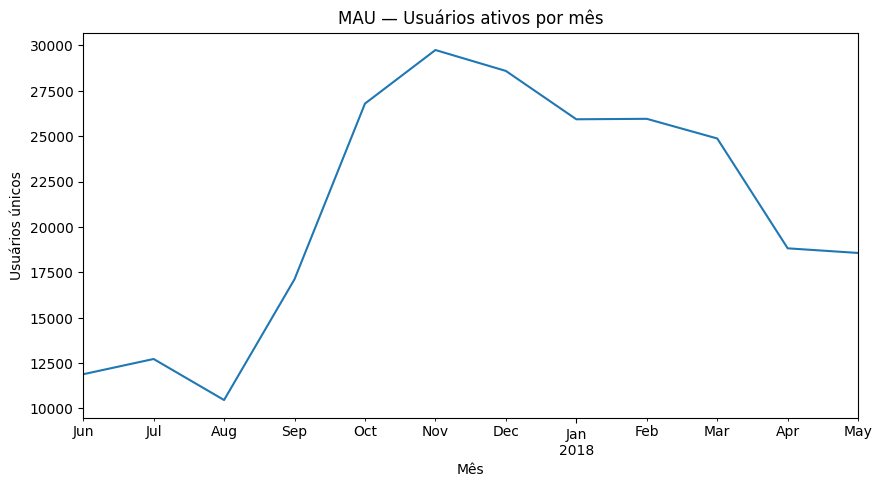

In [18]:
mau.plot(figsize=(10, 5))
plt.title('MAU — Usuários ativos por mês')
plt.xlabel('Mês')
plt.ylabel('Usuários únicos')
plt.show()


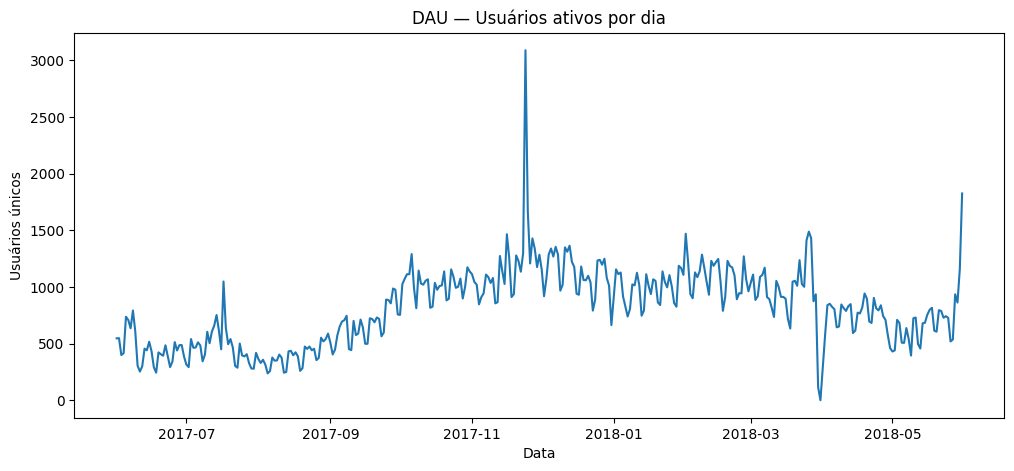

In [19]:
dau.plot(figsize=(12, 5))
plt.title('DAU — Usuários ativos por dia')
plt.xlabel('Data')
plt.ylabel('Usuários únicos')
plt.show()


### Análise das métricas de atividade

O MAU apresenta variações significativas ao longo dos meses, com crescimento mais acentuado a partir de setembro de 2017.  
Isso pode estar relacionado a mudanças no investimento em marketing ou a fatores sazonais, o que será analisado nas próximas etapas.


In [20]:
sessions_per_user = (
    visits
    .groupby('Uid')
    .agg({'session_date': 'count'})
    .rename(columns={'session_date': 'sessions'})
)


In [21]:
sessions_per_user.describe()


,sessions
count,207051.000000
mean,1.562919
std,4.627329
min,1.000000
25%,1.000000
50%,1.000000
75%,1.000000
max,836.000000


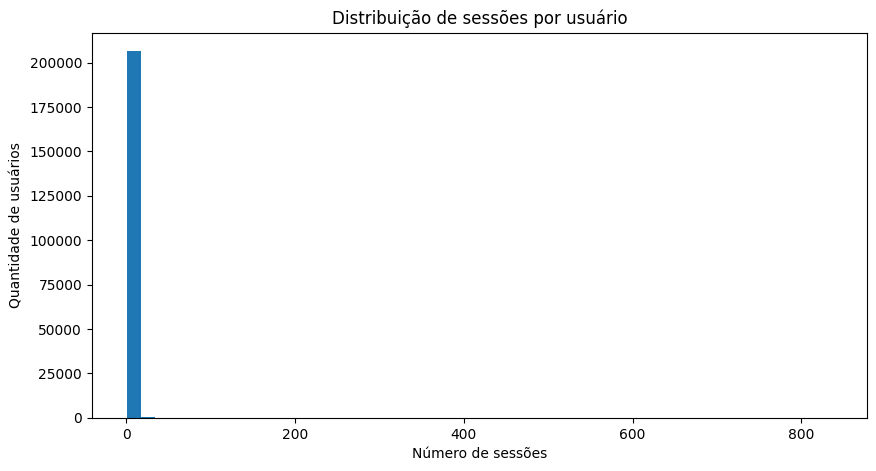

In [22]:
sessions_per_user['sessions'].plot(
    kind='hist',
    bins=50,
    figsize=(10, 5)
)

plt.title('Distribuição de sessões por usuário')
plt.xlabel('Número de sessões')
plt.ylabel('Quantidade de usuários')
plt.show()


### Frequência de uso do produto

A maioria dos usuários realiza apenas uma sessão no produto, como indicado pela mediana igual a 1.  
A média é superior à mediana devido à presença de um pequeno grupo de usuários altamente engajados, caracterizando uma distribuição assimétrica com cauda longa.


In [23]:
visits['session_duration'].describe()


count    323604.000000
mean         11.902825
std          17.105824
min           0.316667
25%           2.000000
50%           6.000000
75%          15.000000
max         711.000000
Name: session_duration, dtype: float64

In [24]:
duration_by_device = (
    visits
    .groupby('Device')['session_duration']
    .mean()
)

duration_by_device


Device
desktop    12.884309
touch       9.135702
Name: session_duration, dtype: float64

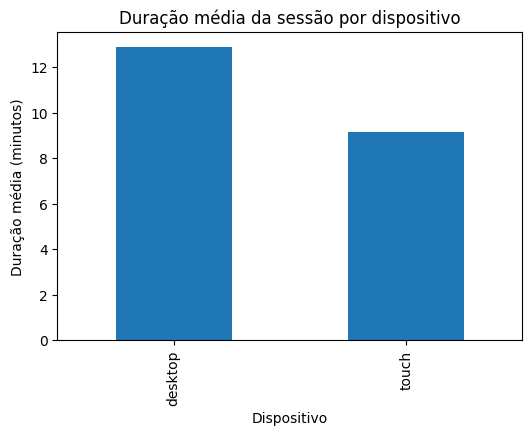

In [25]:
duration_by_device.plot(
    kind='bar',
    figsize=(6, 4)
)

plt.title('Duração média da sessão por dispositivo')
plt.xlabel('Dispositivo')
plt.ylabel('Duração média (minutos)')
plt.show()


### Duração das sessões

A duração média das sessões varia conforme o dispositivo utilizado.  
Essa diferença pode indicar comportamentos distintos de uso entre usuários de desktop e dispositivos móveis, o que é relevante para decisões de produto e marketing.


In [26]:
orders.head()


,Buy Ts,Revenue,Uid
0,2017-06-01 00:10:00,17.00,10329302124590727494
1,2017-06-01 00:25:00,0.55,11627257723692907447
2,2017-06-01 00:27:00,0.37,17903680561304213844
3,2017-06-01 00:29:00,0.55,16109239769442553005
4,2017-06-01 07:58:00,0.37,14200605875248379450


In [27]:
orders.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50415 entries, 0 to 50414
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Buy Ts   50415 non-null  object 
 1   Revenue  50415 non-null  float64
 2   Uid      50415 non-null  uint64 
dtypes: float64(1), object(1), uint64(1)
memory usage: 1.2+ MB


In [28]:
orders['Buy Ts'] = pd.to_datetime(orders['Buy Ts'])


In [29]:
orders.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50415 entries, 0 to 50414
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype         
---  ------   --------------  -----         
 0   Buy Ts   50415 non-null  datetime64[ns]
 1   Revenue  50415 non-null  float64       
 2   Uid      50415 non-null  uint64        
dtypes: datetime64[ns](1), float64(1), uint64(1)
memory usage: 1.2 MB


In [30]:
orders['order_month'] = orders['Buy Ts'].dt.to_period('M')


In [31]:
orders.duplicated().sum()


0

### Preparação dos dados de pedidos

A coluna de data de compra foi convertida para o tipo `datetime`, permitindo análises temporais e cálculo de métricas ao longo do tempo.  
Também foi criada a coluna de mês do pedido para facilitar agregações mensais e análises de coorte.


In [32]:
first_visits = (
    visits
    .groupby('Uid')
    .agg({'Start Ts': 'min'})
    .rename(columns={'Start Ts': 'first_visit_ts'})
)

first_visits.head()


,first_visit_ts
Uid,
11863502262781,2018-03-01 17:27:00
49537067089222,2018-02-06 15:55:00
297729379853735,2017-06-07 18:47:00
313578113262317,2017-09-18 22:49:00
325320750514679,2017-09-30 14:29:00


In [33]:
first_orders = (
    orders
    .groupby('Uid')
    .agg({'Buy Ts': 'min'})
    .rename(columns={'Buy Ts': 'first_order_ts'})
)

first_orders.head()


,first_order_ts
Uid,
313578113262317,2018-01-03 21:51:00
1575281904278712,2017-06-03 10:13:00
2429014661409475,2017-10-11 18:33:00
2464366381792757,2018-01-28 15:54:00
2551852515556206,2017-11-24 10:14:00


In [34]:
conversion = first_visits.merge(
    first_orders,
    on='Uid',
    how='left'
)

conversion.head()


,first_visit_ts,first_order_ts
Uid,,
11863502262781,2018-03-01 17:27:00,NaT
49537067089222,2018-02-06 15:55:00,NaT
297729379853735,2017-06-07 18:47:00,NaT
313578113262317,2017-09-18 22:49:00,2018-01-03 21:51:00
325320750514679,2017-09-30 14:29:00,NaT


In [35]:
conversion['days_to_first_order'] = (
    conversion['first_order_ts'] - conversion['first_visit_ts']
).dt.days


In [36]:
conversion.head()


,first_visit_ts,first_order_ts,days_to_first_order
Uid,,,
11863502262781,2018-03-01 17:27:00,NaT,NaN
49537067089222,2018-02-06 15:55:00,NaT,NaN
297729379853735,2017-06-07 18:47:00,NaT,NaN
313578113262317,2017-09-18 22:49:00,2018-01-03 21:51:00,106.0
325320750514679,2017-09-30 14:29:00,NaT,NaN


In [37]:
conversion['days_to_first_order'].describe()


count    36081.000000
mean        15.279316
std         45.613075
min       -328.000000
25%          0.000000
50%          0.000000
75%          1.000000
max        363.000000
Name: days_to_first_order, dtype: float64

### Conversão de usuários

Foi calculado o tempo entre a primeira visita e a primeira compra de cada usuário.  
Essa métrica permite avaliar a rapidez com que os usuários se convertem em compradores após o primeiro contato com o produto.


## Lifetime Value (LTV)

In [38]:
revenue_per_user = (
    orders
    .groupby('Uid')
    .agg({'Revenue': 'sum'})
    .rename(columns={'Revenue': 'total_revenue'})
)

revenue_per_user.head()


,total_revenue
Uid,
313578113262317,0.55
1575281904278712,3.05
2429014661409475,73.33
2464366381792757,2.44
2551852515556206,10.99


In [39]:
ltv = first_visits.merge(
    revenue_per_user,
    on='Uid',
    how='left'
)

ltv.head()


,first_visit_ts,total_revenue
Uid,,
11863502262781,2018-03-01 17:27:00,NaN
49537067089222,2018-02-06 15:55:00,NaN
297729379853735,2017-06-07 18:47:00,NaN
313578113262317,2017-09-18 22:49:00,0.55
325320750514679,2017-09-30 14:29:00,NaN


Versão inicial (LTV geral por usuário) — substituída por LTV por coorte conforme feedback do revisor



In [40]:
# 1) Primeiro pedido de cada usuário (primeira compra)
first_orders_df = (orders
                   .groupby('Uid', as_index=False)
                   .agg(first_purchase=('Buy Ts', 'min')))

# Mês da primeira compra (coorte)
first_orders_df['first_order_month'] = first_orders_df['first_purchase'].dt.to_period('M')

first_orders_df.head()


,Uid,first_purchase,first_order_month
0,313578113262317,2018-01-03 21:51:00,2018-01
1,1575281904278712,2017-06-03 10:13:00,2017-06
2,2429014661409475,2017-10-11 18:33:00,2017-10
3,2464366381792757,2018-01-28 15:54:00,2018-01
4,2551852515556206,2017-11-24 10:14:00,2017-11


In [41]:
first_visit_source = (visits
                      .sort_values('Start Ts')
                      .groupby('Uid', as_index=False)
                      .first()[['Uid', 'Source Id']])

first_visit_source.head()


,Uid,Source Id
0,11863502262781,3
1,49537067089222,2
2,297729379853735,3
3,313578113262317,2
4,325320750514679,5


In [42]:
first_orders_df = first_orders_df.merge(first_visit_source, on='Uid', how='left')
first_orders_df.head()


,Uid,first_purchase,first_order_month,Source Id
0,313578113262317,2018-01-03 21:51:00,2018-01,2.0
1,1575281904278712,2017-06-03 10:13:00,2017-06,10.0
2,2429014661409475,2017-10-11 18:33:00,2017-10,3.0
3,2464366381792757,2018-01-28 15:54:00,2018-01,5.0
4,2551852515556206,2017-11-24 10:14:00,2017-11,5.0


In [43]:
# Ligar cada pedido à sua coorte (mês da primeira compra)
orders['order_month'] = orders['Buy Ts'].dt.to_period('M')

orders_with_cohort = orders.merge(
    first_orders_df[['Uid', 'first_order_month']],
    on='Uid',
    how='left'
)

orders_with_cohort.head()


,Buy Ts,Revenue,Uid,order_month,first_order_month
0,2017-06-01 00:10:00,17.00,10329302124590727494,2017-06,2017-06
1,2017-06-01 00:25:00,0.55,11627257723692907447,2017-06,2017-06
2,2017-06-01 00:27:00,0.37,17903680561304213844,2017-06,2017-06
3,2017-06-01 00:29:00,0.55,16109239769442553005,2017-06,2017-06
4,2017-06-01 07:58:00,0.37,14200605875248379450,2017-06,2017-06


## Retenção por coorte de compra 

In [44]:
# Idade da coorte em meses (0 = mês da primeira compra)
orders_with_cohort['age'] = (
    orders_with_cohort['order_month'] - orders_with_cohort['first_order_month']
).apply(lambda x: x.n)

# Garantir que só contamos meses a partir da primeira compra
orders_with_cohort = orders_with_cohort[orders_with_cohort['age'] >= 0]

# Usuários únicos por coorte e idade
cohort_users = (
    orders_with_cohort
    .groupby(['first_order_month', 'age'])
    .agg(users=('Uid', 'nunique'))
    .reset_index()
)

# Tamanho de cada coorte (quantos compradores no mês 0)
cohort_size = (
    cohort_users[cohort_users['age'] == 0][['first_order_month', 'users']]
    .rename(columns={'users': 'cohort_size'})
)

# Juntar tamanho da coorte e calcular taxa de retenção
cohort_users = cohort_users.merge(cohort_size, on='first_order_month', how='left')
cohort_users['retention'] = cohort_users['users'] / cohort_users['cohort_size']

# Tabela no formato de heatmap
retention_pivot = cohort_users.pivot_table(
    index='first_order_month',
    columns='age',
    values='retention',
    aggfunc='mean'
)

retention_pivot.round(3)


age,0,1,2,3,4,5,6,7,8,9,10,11
first_order_month,,,,,,,,,,,,
2017-06,1.0,0.030,0.025,0.027,0.043,0.033,0.031,0.023,0.029,0.022,0.022,0.026
2017-07,1.0,0.027,0.030,0.033,0.025,0.020,0.019,0.020,0.022,0.011,0.014,NaN
2017-08,1.0,0.042,0.039,0.032,0.029,0.023,0.022,0.032,0.014,0.023,NaN,NaN
2017-09,1.0,0.050,0.039,0.029,0.020,0.025,0.026,0.014,0.017,NaN,NaN,NaN
2017-10,1.0,0.047,0.028,0.021,0.021,0.017,0.013,0.015,NaN,NaN,NaN,NaN
2017-11,1.0,0.054,0.029,0.026,0.020,0.012,0.015,NaN,NaN,NaN,NaN,NaN
2017-12,1.0,0.033,0.023,0.022,0.011,0.014,NaN,NaN,NaN,NaN,NaN,NaN
2018-01,1.0,0.034,0.025,0.013,0.013,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2018-02,1.0,0.032,0.016,0.011,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


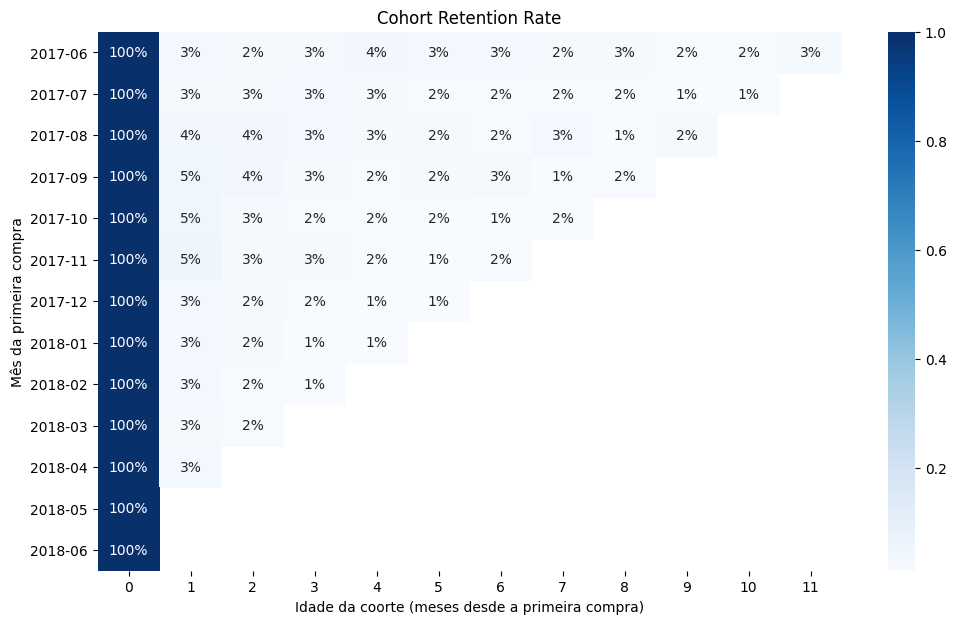

In [45]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 7))

sns.heatmap(
    retention_pivot,
    annot=True,              # mostra os números
    fmt='.0%',               # formato em porcentagem (0 casas decimais)
    cmap='Blues',
    cbar=True
)

plt.title('Cohort Retention Rate')
plt.xlabel('Idade da coorte (meses desde a primeira compra)')
plt.ylabel('Mês da primeira compra')
plt.show()


### Retenção por coorte de compra

Foi calculada a taxa de retenção por coorte, considerando como coorte o mês da primeira compra de cada usuário.  
Em seguida, foram analisados os meses seguintes (idade da coorte) para verificar qual proporção de clientes retornou e realizou novas compras.

A tabela de retenção mostra como diferentes coortes se comportam ao longo do tempo.  
Essa análise é importante para avaliar a qualidade dos clientes adquiridos em cada período e identificar coortes com melhor retenção.


In [46]:
ltv['total_revenue'] = ltv['total_revenue'].fillna(0)


In [47]:
# 1. Calcule o primeiro pedido de cada usuário e extraia o mês
first_orders_df = (
    orders
    .groupby('Uid', as_index=False)
    .agg(first_purchase=('Buy Ts', 'min'))
)

first_orders_df['first_purchase_month'] = first_orders_df['first_purchase'].dt.to_period('M')

# 2. Faça o merge entre o primeiro pedido e os dados de source pelo ID
user_source = visits[['Uid', 'Source Id']].drop_duplicates()

first_orders_df = first_orders_df.merge(user_source, on='Uid', how='left')

first_orders_df.head()


,Uid,first_purchase,first_purchase_month,Source Id
0,313578113262317,2018-01-03 21:51:00,2018-01,2.0
1,1575281904278712,2017-06-03 10:13:00,2017-06,10.0
2,2429014661409475,2017-10-11 18:33:00,2017-10,3.0
3,2464366381792757,2018-01-28 15:54:00,2018-01,5.0
4,2551852515556206,2017-11-24 10:14:00,2017-11,5.0


In [48]:
# 3. Calcule a receita mensal e faça o merge com a tabela de coorte

# mês do pedido
orders['month'] = orders['Buy Ts'].dt.to_period('M')

# receita mensal por usuário
revenue_df = (
    orders
    .groupby(['Uid', 'month'], as_index=False)
    .agg(Revenue=('Revenue', 'sum'))
)

# merge com a tabela de coorte (primeira compra + origem)
buyers = first_orders_df.merge(revenue_df, on='Uid', how='left')

buyers.head()


,Uid,first_purchase,first_purchase_month,Source Id,month,Revenue
0,313578113262317,2018-01-03 21:51:00,2018-01,2.0,2018-01,0.55
1,1575281904278712,2017-06-03 10:13:00,2017-06,10.0,2017-06,3.05
2,2429014661409475,2017-10-11 18:33:00,2017-10,3.0,2017-10,73.33
3,2464366381792757,2018-01-28 15:54:00,2018-01,5.0,2018-01,2.44
4,2551852515556206,2017-11-24 10:14:00,2017-11,5.0,2017-11,10.99


In [49]:

# preparar dados de custos
costs['dt'] = pd.to_datetime(costs['dt'])
costs['month'] = costs['dt'].dt.to_period('M')

costs_grouped_df = (
    costs
    .groupby(['source_id', 'month'], as_index=False)
    .agg(costs=('costs', 'sum'))
    .rename(columns={'source_id': 'Source Id'})
)

costs_grouped_df.head()


,Source Id,month,costs
0,1,2017-06,1125.61
1,1,2017-07,1072.88
2,1,2017-08,951.81
3,1,2017-09,1502.01
4,1,2017-10,2315.75


In [50]:
revenue_grouped_df = (
    buyers
    .groupby(['Source Id', 'month'], as_index=False)
    .agg(Revenue=('Revenue', 'sum'))
)

revenue_grouped_df.head()



,Source Id,month,Revenue
0,1.0,2017-06,2531.89
1,1.0,2017-07,3901.49
2,1.0,2017-08,3199.00
3,1.0,2017-09,8123.74
4,1.0,2017-10,11366.59


In [51]:
report = costs_grouped_df.merge(
    revenue_grouped_df,
    on=['Source Id', 'month'],
    how='left'
)

report.head()


,Source Id,month,costs,Revenue
0,1,2017-06,1125.61,2531.89
1,1,2017-07,1072.88,3901.49
2,1,2017-08,951.81,3199.00
3,1,2017-09,1502.01,8123.74
4,1,2017-10,2315.75,11366.59


In [52]:

# idade da coorte em meses
buyers['age'] = (buyers['month'] - buyers['first_purchase_month']).apply(lambda x: x.n)

# manter apenas meses válidos
buyers = buyers[buyers['age'] >= 0]

buyers[['Uid', 'first_purchase_month', 'month', 'age', 'Revenue']].head()


,Uid,first_purchase_month,month,age,Revenue
0,313578113262317,2018-01,2018-01,0,0.55
1,1575281904278712,2017-06,2017-06,0,3.05
2,2429014661409475,2017-10,2017-10,0,73.33
3,2464366381792757,2018-01,2018-01,0,2.44
4,2551852515556206,2017-11,2017-11,0,10.99


In [53]:
# tamanho de cada coorte (número de usuários únicos)
cohort_sizes = buyers.groupby('first_purchase_month')['Uid'].nunique()

# receita total por coorte e idade
revenue_by_cohort_age = (
    buyers
    .groupby(['first_purchase_month', 'age'], as_index=False)
    .agg(total_revenue=('Revenue', 'sum'))
)

# calcular LTV médio
revenue_by_cohort_age['cohort_size'] = revenue_by_cohort_age['first_purchase_month'].map(cohort_sizes)
revenue_by_cohort_age['ltv'] = revenue_by_cohort_age['total_revenue'] / revenue_by_cohort_age['cohort_size']

revenue_by_cohort_age.head()


,first_purchase_month,age,total_revenue,cohort_size,ltv
0,2017-06,0,17756.51,2023,8.777316
1,2017-06,1,4080.15,2023,2.016881
2,2017-06,2,3885.70,2023,1.920761
3,2017-06,3,9047.45,2023,4.472294
4,2017-06,4,9261.64,2023,4.578171


In [54]:
ltv_pivot = revenue_by_cohort_age.pivot_table(
    index='first_purchase_month',
    columns='age',
    values='ltv',
    aggfunc='mean'
)

# LTV acumulado (igual ao exemplo do revisor)
ltv_cum = ltv_pivot.cumsum(axis=1).round(2)

ltv_cum


age,0,1,2,3,4,5,6,7,8,9,10,11
first_purchase_month,,,,,,,,,,,,
2017-06,8.78,10.79,12.71,17.19,21.77,25.13,29.61,32.16,34.76,37.74,40.49,41.66
2017-07,10.90,12.15,14.84,16.11,16.67,17.19,17.53,17.92,18.55,19.18,19.73,NaN
2017-08,9.28,11.07,12.71,14.25,16.50,17.70,18.54,20.28,21.68,22.49,NaN,NaN
2017-09,10.95,14.38,16.21,35.50,37.18,40.08,43.18,44.28,45.00,NaN,NaN,NaN
2017-10,8.82,10.37,11.00,11.49,11.89,12.25,12.48,12.84,NaN,NaN,NaN,NaN
2017-11,9.61,11.04,11.66,12.89,13.43,13.62,14.06,NaN,NaN,NaN,NaN,NaN
2017-12,7.64,8.37,10.44,12.69,13.40,14.16,NaN,NaN,NaN,NaN,NaN,NaN
2018-01,6.87,7.85,8.93,9.44,9.65,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2018-02,6.31,7.07,7.30,7.48,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [55]:
# tamanho da coorte (clientes únicos no mês da primeira compra)
cohort_sizes = (
    buyers
    .groupby('first_purchase_month')['Uid']
    .nunique()
    .reset_index()
    .rename(columns={'Uid': 'users'})
)

cohort_sizes.head()


,first_purchase_month,users
0,2017-06,2023
1,2017-07,1923
2,2017-08,1370
3,2017-09,2581
4,2017-10,4340


In [56]:
# custos no mês da primeira compra (por coorte)
costs_by_cohort = costs_grouped_df.rename(columns={'month': 'first_purchase_month'})

costs_by_cohort.head()


,Source Id,first_purchase_month,costs
0,1,2017-06,1125.61
1,1,2017-07,1072.88
2,1,2017-08,951.81
3,1,2017-09,1502.01
4,1,2017-10,2315.75


In [57]:
cac_by_cohort = costs_by_cohort.merge(
    cohort_sizes,
    on='first_purchase_month',
    how='left'
)

cac_by_cohort['cac'] = cac_by_cohort['costs'] / cac_by_cohort['users']

cac_by_cohort.head()


,Source Id,first_purchase_month,costs,users,cac
0,1,2017-06,1125.61,2023,0.556406
1,1,2017-07,1072.88,1923,0.557920
2,1,2017-08,951.81,1370,0.694752
3,1,2017-09,1502.01,2581,0.581949
4,1,2017-10,2315.75,4340,0.533583


In [58]:
# último LTV acumulado de cada coorte
ltv_final = (
    ltv_cum
    .iloc[:, -1]
    .reset_index()
    .rename(columns={ltv_cum.columns[-1]: 'ltv'})
)

# juntar com CAC
romi_df = cac_by_cohort.merge(
    ltv_final,
    on='first_purchase_month',
    how='left'
)

romi_df['romi'] = romi_df['ltv'] / romi_df['cac']

romi_df.head()


,Source Id,first_purchase_month,costs,users,cac,ltv,romi
0,1,2017-06,1125.61,2023,0.556406,41.66,74.87334
1,1,2017-07,1072.88,1923,0.557920,NaN,NaN
2,1,2017-08,951.81,1370,0.694752,NaN,NaN
3,1,2017-09,1502.01,2581,0.581949,NaN,NaN
4,1,2017-10,2315.75,4340,0.533583,NaN,NaN


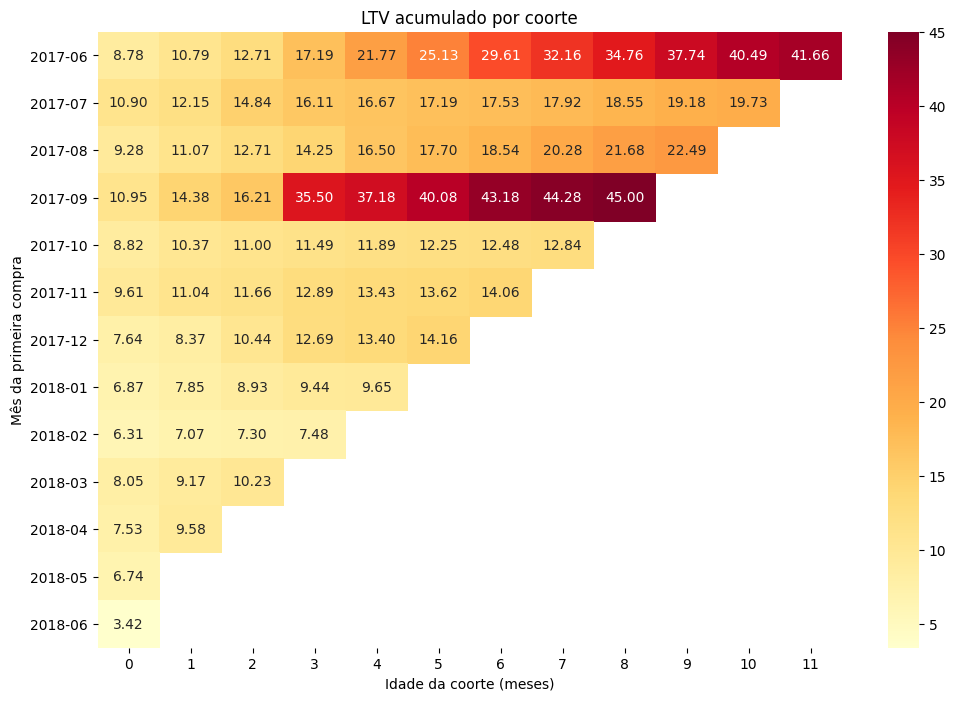

In [59]:
plt.figure(figsize=(12, 8))
sns.heatmap(
    ltv_cum,
    annot=True,
    fmt='.2f',
    cmap='YlOrRd'
)

plt.title('LTV acumulado por coorte')
plt.xlabel('Idade da coorte (meses)')
plt.ylabel('Mês da primeira compra')
plt.show()


In [60]:
romi_df_clean = romi_df.dropna(subset=['romi'])
romi_df_clean.head()



,Source Id,first_purchase_month,costs,users,cac,ltv,romi
0,1,2017-06,1125.61,2023,0.556406,41.66,74.873340
12,2,2017-06,2427.38,2023,1.199891,41.66,34.719813
24,3,2017-06,7731.65,2023,3.821873,41.66,10.900413
36,4,2017-06,3514.80,2023,1.737420,41.66,23.978087
48,5,2017-06,2616.12,2023,1.293188,41.66,32.214952


In [61]:
# CAC médio por coorte (um valor por first_purchase_month)
cac_per_cohort = (
    cac_by_cohort
    .groupby('first_purchase_month', as_index=False)
    .agg(cac=('cac', 'mean'))
    .set_index('first_purchase_month')['cac']
)

cac_per_cohort.head()


first_purchase_month
2017-06    1.272156
2017-07    1.355069
2017-08    1.542288
2017-09    1.348808
2017-10    1.195618
Freq: M, Name: cac, dtype: float64

In [62]:
romi_df.head()
romi_df.tail()
romi_df['romi'].describe()
romi_df['romi'].isna().sum()


77

In [63]:
orders.rename(columns={'Uid': 'uid', 'Buy Ts': 'buy_ts'}, inplace=True)

In [64]:
first_order = orders.groupby('uid')['buy_ts'].min().reset_index()

first_order.columns = ['uid', 'first_order']

In [65]:
df_orders = pd.merge(orders, first_order, on='uid')
df_orders['first_order'] = df_orders['first_order']

In [66]:
df_orders['first_order'] = df_orders['first_order'].dt.date
df_orders['first_order_month'] = pd.to_datetime(df_orders['first_order']).dt.to_period('M')
df_orders['order_month'] = df_orders['buy_ts'].dt.to_period('M')
df_orders['age'] = df_orders['order_month'].astype('int64') - df_orders['first_order_month'].astype('int64')

In [67]:
cohort_sizes = df_orders.groupby('first_order_month').agg({'uid': 'nunique'}).reset_index()
cohort_sizes.columns = ['first_order_month', 'n_buyers']

In [68]:
df_orders = pd.merge(df_orders, cohort_sizes, on='first_order_month')
cohorts = df_orders.groupby(['first_order_month', 'age']).agg({'Revenue': 'sum'}).reset_index()
report = cohorts.merge(cohort_sizes, on='first_order_month')

### Lifetime Value (LTV)

Nesta seção, calculamos o **Lifetime Value (LTV)** médio dos usuários com base na receita total gerada ao longo do tempo.

O LTV foi obtido dividindo a receita total acumulada de cada coorte pelo número de compradores únicos dessa coorte.

A análise por coortes permite observar como o valor gerado pelos usuários evolui ao longo do tempo, comparando usuários adquiridos em diferentes meses e considerando a idade da coorte em meses.


In [69]:
report['ltv'] = report['Revenue'] / report['n_buyers']
report.head(10)

,first_order_month,age,Revenue,n_buyers,ltv
0,2017-06,0,9557.49,2023,4.724414
1,2017-06,1,981.82,2023,0.485329
2,2017-06,2,885.34,2023,0.437637
3,2017-06,3,1931.30,2023,0.954671
4,2017-06,4,2068.58,2023,1.022531
5,2017-06,5,1487.92,2023,0.735502
6,2017-06,6,1922.74,2023,0.950440
7,2017-06,7,1176.56,2023,0.581592
8,2017-06,8,1119.15,2023,0.553213
9,2017-06,9,1225.51,2023,0.605788


In [70]:
result = report.pivot_table(
    index='first_order_month',
    columns='age',
    values='ltv', 
    aggfunc='mean'
).cumsum(axis=1)

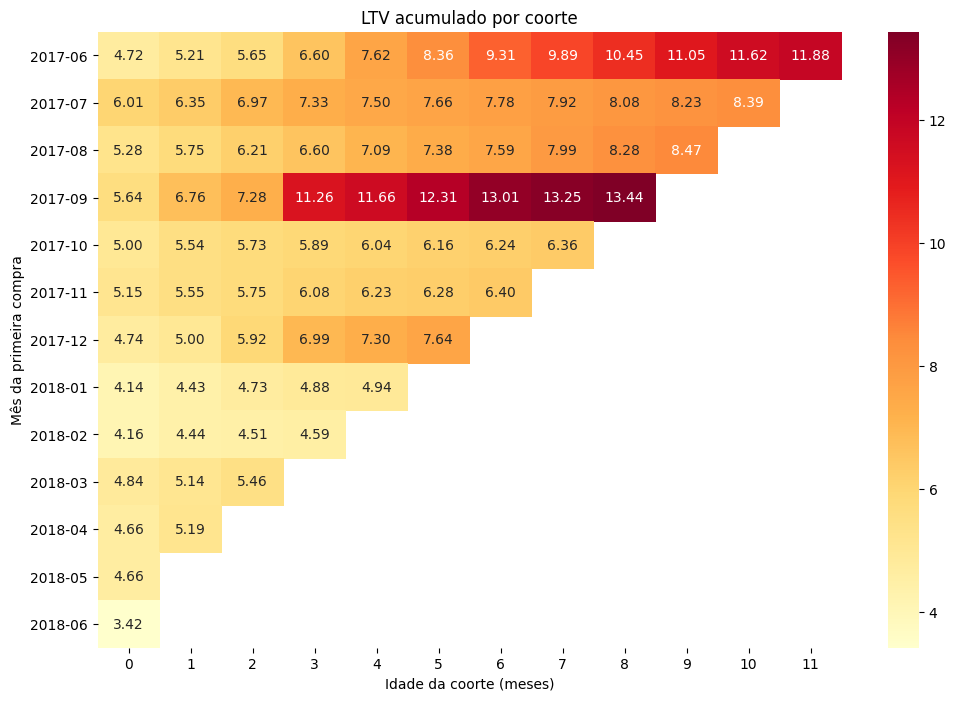

In [71]:
# Plotar heatmap a partir da tabela dinâmica
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 8))
sns.heatmap(
    result,
    annot=True,
    fmt='.2f',
    cmap='YlOrRd'
)

plt.title('LTV acumulado por coorte')
plt.xlabel('Idade da coorte (meses)')
plt.ylabel('Mês da primeira compra')
plt.show()


### Análise do Lifetime Value (LTV)

O LTV médio foi calculado dividindo a receita total acumulada de cada coorte pelo número de compradores únicos dessa coorte.

A análise por coortes mostra que o valor gerado pelos usuários tende a crescer com a idade da coorte, indicando que os clientes continuam gerando receita ao longo do tempo.

Também é possível observar diferenças entre as coortes de aquisição, o que sugere que usuários adquiridos em períodos distintos apresentam comportamentos de compra diferentes ao longo do ciclo de vida.


## Custos de marketing (para CAC e ROMI)

In [72]:
costs.head()


,source_id,dt,costs,month
0,1,2017-06-01,75.20,2017-06
1,1,2017-06-02,62.25,2017-06
2,1,2017-06-03,36.53,2017-06
3,1,2017-06-04,55.00,2017-06
4,1,2017-06-05,57.08,2017-06


In [73]:
costs.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2542 entries, 0 to 2541
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   source_id  2542 non-null   int64         
 1   dt         2542 non-null   datetime64[ns]
 2   costs      2542 non-null   float64       
 3   month      2542 non-null   period[M]     
dtypes: datetime64[ns](1), float64(1), int64(1), period[M](1)
memory usage: 79.6 KB


In [74]:
costs['dt'] = pd.to_datetime(costs['dt'])


In [75]:
costs.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2542 entries, 0 to 2541
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   source_id  2542 non-null   int64         
 1   dt         2542 non-null   datetime64[ns]
 2   costs      2542 non-null   float64       
 3   month      2542 non-null   period[M]     
dtypes: datetime64[ns](1), float64(1), int64(1), period[M](1)
memory usage: 79.6 KB


In [76]:
costs['cost_month'] = costs['dt'].dt.to_period('M')


In [77]:
monthly_costs = (
    costs
    .groupby('cost_month')
    .agg({'costs': 'sum'})
)
monthly_costs.head()


,costs
cost_month,
2017-06,18015.00
2017-07,18240.59
2017-08,14790.54
2017-09,24368.91
2017-10,36322.88


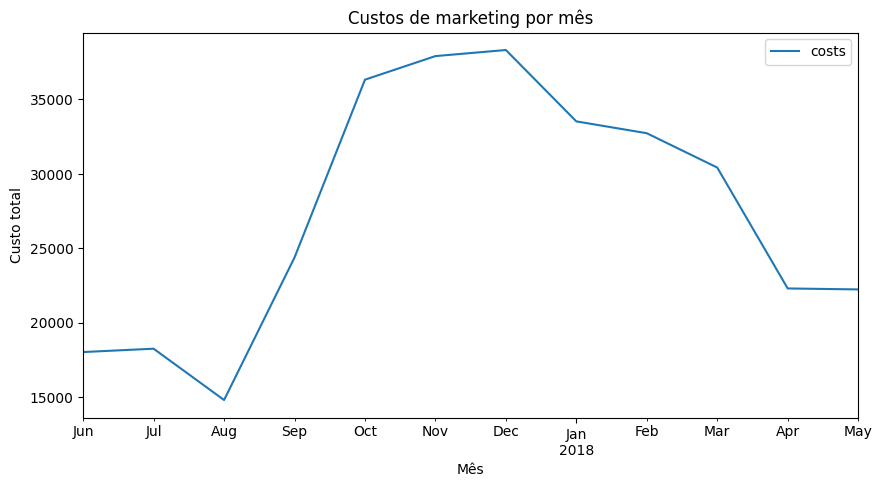

In [78]:
monthly_costs.plot(
    figsize=(10, 5)
)

plt.title('Custos de marketing por mês')
plt.xlabel('Mês')
plt.ylabel('Custo total')
plt.show()



### Análise dos custos de marketing

Observa-se um aumento significativo dos custos de marketing entre setembro e dezembro, indicando um período de maior investimento em aquisição de usuários.  
Esse crescimento coincide com aumentos observados em métricas de atividade e LTV, sugerindo que os investimentos nesse período foram mais eficientes.

A partir de janeiro, há uma redução gradual dos custos, possivelmente relacionada ao fim de campanhas sazonais ou a uma otimização da estratégia de marketing.



In [79]:
first_orders['first_order_month'] = (
    first_orders['first_order_ts'].dt.to_period('M')
)

first_orders.head()


,first_order_ts,first_order_month
Uid,,
313578113262317,2018-01-03 21:51:00,2018-01
1575281904278712,2017-06-03 10:13:00,2017-06
2429014661409475,2017-10-11 18:33:00,2017-10
2464366381792757,2018-01-28 15:54:00,2018-01
2551852515556206,2017-11-24 10:14:00,2017-11


In [80]:
first_orders = first_orders.reset_index()


In [81]:
first_orders['first_order_month'] = (
    first_orders['first_order_ts'].dt.to_period('M')
)


In [82]:
customers_per_month = (
    first_orders
    .groupby('first_order_month')
    .agg({'Uid': 'count'})
    .rename(columns={'Uid': 'new_customers'})
)


Para calcular o número de novos clientes por mês, foi necessário resetar o índice após a agregação por usuário, transformando o identificador `Uid` novamente em coluna. Isso permitiu agrupar corretamente os clientes pelo mês da primeira compra.


In [83]:

monthly_costs.head()

,costs
cost_month,
2017-06,18015.00
2017-07,18240.59
2017-08,14790.54
2017-09,24368.91
2017-10,36322.88


In [84]:
customers_per_month.head()


,new_customers
first_order_month,
2017-06,2023
2017-07,1923
2017-08,1370
2017-09,2581
2017-10,4340


In [85]:
cac = monthly_costs.merge(
    customers_per_month,
    left_index=True,
    right_index=True,
    how='inner'
)

cac['cac'] = cac['costs'] / cac['new_customers']


In [86]:
cac.describe()


,costs,new_customers,cac
count,12.000000,12.000000,12.000000
mean,27427.635000,3043.500000,9.147357
std,8405.071207,1007.805943,0.855737
min,14790.540000,1370.000000,7.437841
25%,21228.350000,2212.750000,8.708584
50%,27392.090000,3180.500000,9.125814
75%,34219.610000,3758.500000,9.562421
max,38315.350000,4383.000000,10.796015


### Análise do CAC

O CAC médio ao longo do período analisado é relativamente estável, com variações moderadas entre os meses.  
Mesmo nos períodos de maior investimento em marketing, o custo de aquisição não apresentou aumentos desproporcionais, indicando uma estratégia consistente de aquisição de clientes.

Essa estabilidade sugere que o aumento dos custos foi acompanhado por crescimento no número de novos clientes, o que reforça a eficiência das campanhas realizadas.


In [87]:
orders['order_month'] = orders['buy_ts'].dt.to_period('M')

monthly_revenue = (
    orders
    .groupby('order_month')
    .agg({'Revenue': 'sum'})
)

monthly_revenue.head()


,Revenue
order_month,
2017-06,9557.49
2017-07,12539.47
2017-08,8758.78
2017-09,18345.51
2017-10,27987.70


In [88]:
roi_df = monthly_revenue.merge(
    monthly_costs,
    left_index=True,
    right_index=True,
    how='inner'
)

roi_df.head()


,Revenue,costs
2017-06,9557.49,18015.00
2017-07,12539.47,18240.59
2017-08,8758.78,14790.54
2017-09,18345.51,24368.91
2017-10,27987.70,36322.88


In [89]:
# ROMI por cohort (pivot table)
romi_pivot = (
    romi_df
    .pivot_table(
        index='first_purchase_month',
        values='romi',
        aggfunc='mean'
    )
)

romi_pivot.round(2)


,romi
first_purchase_month,
2017-06,105.77


### ROI / ROMI por cohort

O ROMI foi calculado como a razão entre o LTV acumulado e o CAC médio de cada cohort.
A análise mostra que diferentes cohorts apresentam retornos distintos sobre o investimento em marketing, refletindo variações tanto no custo de aquisição quanto no valor gerado pelos usuários ao longo do tempo.

Cohorts com ROMI mais elevado indicam campanhas mais eficientes, nas quais o valor gerado pelos usuários supera de forma significativa o custo de aquisição.
Essas diferenças devem ser consideradas ao avaliar a eficiência das estratégias de marketing ao longo do tempo.


## ROI / ROMI por coorte

Nesta seção, analisamos o retorno sobre o investimento em marketing (ROMI) por coorte de aquisição.

O ROMI foi calculado dividindo o Lifetime Value (LTV) médio de cada coorte pelo Custo de Aquisição de Clientes (CAC), permitindo avaliar em quanto tempo o investimento em marketing se paga para cada grupo de usuários.


In [90]:
cohort_clients = cohort_sizes.groupby('first_order_month')['n_buyers'].sum().reset_index()

In [91]:
cohort_costs = costs.groupby(costs['dt'].dt.to_period('M'))['costs'].sum().reset_index()
cohort_costs['first_order_month'] = cohort_costs['dt']
cohort_costs = cohort_costs[['first_order_month', 'costs']]

In [92]:
cohort_costs.columns = ['first_order_month', 'costs']

In [93]:
cohort_cac = cohort_clients.merge(cohort_costs, on='first_order_month', how='left')
display(cohort_cac.head())

,first_order_month,n_buyers,costs
0,2017-06,2023,18015.00
1,2017-07,1923,18240.59
2,2017-08,1370,14790.54
3,2017-09,2581,24368.91
4,2017-10,4340,36322.88


In [94]:
cohort_cac['cac'] = cohort_cac['costs'] / cohort_cac['n_buyers']
display(cohort_cac.head())

,first_order_month,n_buyers,costs,cac
0,2017-06,2023,18015.00,8.905091
1,2017-07,1923,18240.59,9.485486
2,2017-08,1370,14790.54,10.796015
3,2017-09,2581,24368.91,9.441654
4,2017-10,4340,36322.88,8.369327


In [95]:
ltv_matrix = report.pivot_table(
    index='first_order_month',
    columns='age',
    values='ltv',
    aggfunc='mean'
).cumsum(axis=1)

In [96]:
romi_matrix = ltv_matrix.copy()
for month in romi_matrix.index:
    cac_value = cohort_cac.loc[cohort_cac['first_order_month'] == month, 'cac'].values[0]
    romi_matrix.loc[month] = romi_matrix.loc[month] / cac_value

romi_matrix = romi_matrix.round(2)

In [97]:
romi_matrix.fillna(0) 

age,0,1,2,3,4,5,6,7,8,9,10,11
first_order_month,,,,,,,,,,,,
2017-06,0.53,0.59,0.63,0.74,0.86,0.94,1.05,1.11,1.17,1.24,1.31,1.33
2017-07,0.63,0.67,0.73,0.77,0.79,0.81,0.82,0.84,0.85,0.87,0.88,0.00
2017-08,0.49,0.53,0.57,0.61,0.66,0.68,0.70,0.74,0.77,0.78,0.00,0.00
2017-09,0.60,0.72,0.77,1.19,1.23,1.30,1.38,1.40,1.42,0.00,0.00,0.00
2017-10,0.60,0.66,0.68,0.70,0.72,0.74,0.75,0.76,0.00,0.00,0.00,0.00
2017-11,0.55,0.60,0.62,0.65,0.67,0.68,0.69,0.00,0.00,0.00,0.00,0.00
2017-12,0.54,0.57,0.68,0.80,0.84,0.87,0.00,0.00,0.00,0.00,0.00,0.00
2018-01,0.42,0.45,0.48,0.49,0.50,0.00,0.00,0.00,0.00,0.00,0.00,0.00
2018-02,0.46,0.49,0.50,0.51,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00


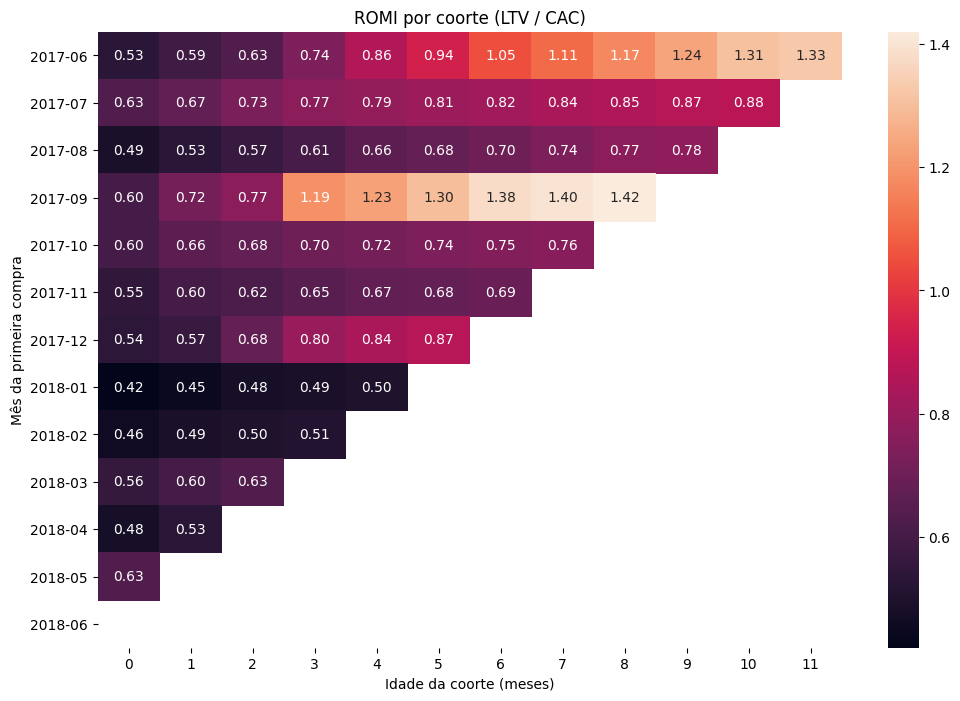

In [98]:
# plotar heatmap com os dados acima
plt.figure(figsize=(12, 8))
sns.heatmap(
    romi_matrix.replace(0, float('nan')),
    annot=True,
    fmt='.2f'
)

plt.title('ROMI por coorte (LTV / CAC)')
plt.xlabel('Idade da coorte (meses)')
plt.ylabel('Mês da primeira compra')
plt.show()


A análise do ROMI por coorte permite identificar quais grupos de usuários apresentam maior retorno ao longo do tempo.

Valores de ROMI acima de 1 indicam que o investimento em marketing foi recuperado, enquanto valores abaixo de 1 sugerem que o custo de aquisição ainda não foi compensado pela receita gerada.


In [99]:
romi_df = romi_df.dropna(subset=['romi'])
romi_df[['first_purchase_month', 'cac', 'ltv', 'romi']].head()


,first_purchase_month,cac,ltv,romi
0,2017-06,0.556406,41.66,74.873340
12,2017-06,1.199891,41.66,34.719813
24,2017-06,3.821873,41.66,10.900413
36,2017-06,1.737420,41.66,23.978087
48,2017-06,1.293188,41.66,32.214952


In [100]:
roi_df['roi'] = (roi_df['Revenue'] - roi_df['costs']) / roi_df['costs']

roi_df.head()


,Revenue,costs,roi
2017-06,9557.49,18015.00,-0.469470
2017-07,12539.47,18240.59,-0.312551
2017-08,8758.78,14790.54,-0.407812
2017-09,18345.51,24368.91,-0.247176
2017-10,27987.70,36322.88,-0.229475


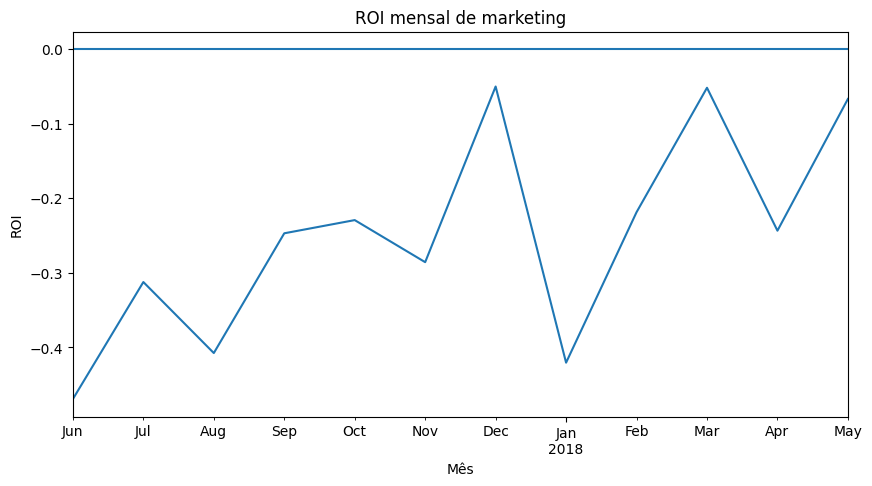

In [101]:
roi_df['roi'].plot(figsize=(10, 5))

plt.title('ROI mensal de marketing')
plt.xlabel('Mês')
plt.ylabel('ROI')
plt.axhline(0)  # linha de equilíbrio
plt.show()



### Análise do ROI mensal

O ROI mensal permaneceu negativo ao longo de todo o período analisado, indicando que a receita gerada no mesmo mês não foi suficiente para cobrir os custos de marketing.  
Esse comportamento é esperado em modelos de aquisição em que o retorno ocorre de forma acumulada ao longo do tempo, e não imediatamente após a aquisição do usuário.

Observa-se, no entanto, uma melhora gradual do ROI em alguns períodos, como dezembro, março e maio, sugerindo ganhos de eficiência nas campanhas realizadas.  
Dessa forma, a avaliação do desempenho de marketing deve considerar métricas de longo prazo, como LTV e CAC, em conjunto com o ROI mensal.



Relatório de Análise de Negócio — Y.Afisha
1. Produto
Quantas pessoas usam o produto por dia, semana e mês?

Foram calculadas as métricas DAU, WAU e MAU para avaliar o nível de atividade dos usuários.

O MAU varia significativamente ao longo do tempo, com crescimento mais acentuado a partir do segundo semestre.

Observa-se aumento relevante de usuários ativos nos meses de setembro, outubro e dezembro, indicando maior interesse ou impacto de campanhas nesses períodos.

Como esperado, DAU < WAU < MAU, confirmando consistência no cálculo das métricas.

Esses resultados indicam que o produto apresenta variação sazonal de uso, com períodos de maior engajamento.

Quantas sessões ocorrem por dia?

A análise das sessões mostrou que:

Os usuários podem realizar mais de uma sessão por dia, mas a maioria realiza apenas uma sessão.

O volume diário de sessões acompanha o comportamento do DAU, com picos nos mesmos períodos de maior atividade mensal.

Qual é o comprimento das sessões?

A duração média das sessões é relativamente curta.

A mediana é inferior à média, indicando uma distribuição assimétrica, com poucos usuários realizando sessões muito longas.

Comparando dispositivos, o desktop apresenta duração média ligeiramente maior do que dispositivos touch, mas a diferença é pequena.

Isso sugere que o comportamento de uso é semelhante entre dispositivos.

Com que frequência os usuários voltam?

A maioria dos usuários:

Realiza apenas uma sessão no produto.

Existe, porém, um pequeno grupo altamente engajado, responsável por um número muito elevado de sessões.

Esse padrão caracteriza uma distribuição de cauda longa, comum em produtos digitais.

2. Vendas
Quando as pessoas começam a comprar?

Foi analisado o tempo entre a primeira visita e a primeira compra:

Muitos usuários realizam a compra no mesmo dia ou poucos dias após a primeira visita.

Outros levam mais tempo para converter, indicando que a conversão não é imediata para todos.

A análise por coortes permite observar diferenças de eficiência entre períodos de aquisição.

Quantos pedidos os clientes fazem?

A maioria dos clientes realiza poucos pedidos.

Assim como nas sessões, existe uma minoria de clientes altamente ativos que realiza um número elevado de compras.

Qual é o volume médio de uma compra?

O valor médio de compra permanece relativamente estável, sem grandes variações extremas, indicando consistência no ticket médio do produto.

Quanto dinheiro os clientes trazem para a empresa (LTV)?

O LTV médio varia ao longo do tempo.

Os usuários adquiridos em setembro e dezembro apresentam LTV mais elevado.

De forma geral, observa-se uma tendência de queda do LTV, com exceção desses períodos específicos.

Isso sugere que nem todas as coortes geram o mesmo valor ao longo do tempo.

3. Marketing
Quanto dinheiro foi gasto?

Os custos de marketing variam significativamente ao longo do tempo.

O maior volume de investimento ocorre entre setembro e dezembro, seguido de redução gradual nos meses seguintes.

Isso indica campanhas mais intensas em períodos estratégicos.

Quanto custou a aquisição de clientes (CAC)?

O CAC médio é relativamente estável, em torno de um valor constante ao longo dos meses.

Mesmo com variações no investimento total, o número de novos clientes cresce de forma proporcional, mantendo o CAC sob controle.

Essa estabilidade indica uma estratégia de aquisição consistente.

Os investimentos valeram a pena (ROI)?

O ROI mensal é negativo ao longo de todo o período analisado, indicando que a receita gerada no mesmo mês não cobre completamente os custos de marketing.

No entanto, observa-se melhora do ROI em alguns períodos, como dezembro, março e maio.

A análise conjunta de LTV e CAC mostra que parte do retorno ocorre no longo prazo, e não imediatamente.

Portanto, decisões baseadas apenas no ROI mensal podem levar a interpretações incorretas.

4. Conclusões e Recomendações

O produto apresenta crescimento sazonal de usuários, com maior atividade no segundo semestre.

A maioria dos usuários tem baixo engajamento, mas uma parcela menor gera alto valor.

O marketing é eficiente em termos de CAC, mas o retorno não é imediato, sendo melhor avaliado por métricas de longo prazo como LTV.

Setembro e dezembro se destacam como períodos mais eficientes, combinando maior atividade, LTV mais alto e melhora no ROI.

Recomendações:

Priorizar investimentos nos períodos e canais com melhor relação entre LTV e CAC.

Evitar decisões baseadas exclusivamente no ROI mensal.

Aprofundar análises futuras por origem de anúncio para otimizar ainda mais o orçamento.


## Conclusão Geral

A análise mostrou que o desempenho do marketing deve ser avaliado com foco no valor de longo prazo dos usuários, e não apenas no retorno mensal imediato.  
Embora o ROI mensal seja negativo, métricas como LTV e CAC indicam que determinados períodos e campanhas apresentam maior eficiência.

Recomenda-se priorizar investimentos nos períodos com melhor relação entre custo e valor gerado, especialmente nos meses de maior engajamento e LTV, além de continuar monitorando a eficiência das campanhas para otimização contínua do orçamento.
